# Question 10: Hill Climbing Variants
Function: f(x) = -(x-3)^2 + 9

In [1]:
from datetime import datetime
import numpy as np
import matplotlib.pyplot as plt
import random

## (a) Simple Hill Climbing
- Start from x0 = 0.0 with step size 0.1
- Move to the first neighbor that improves f(x)
- Stop when no improvement occurs

In [3]:
print(datetime.now())
print("F24-0688")

def f(x):
    return -(x-3)**2 + 9

def simple_hill_climb(x0=0.0, step=0.1):
    x = x0
    path = [x]

    while True:
        neighbors = [x + step, x - step]
        moved = False

        for n in neighbors:
            if f(n) > f(x):
                x = n
                path.append(x)
                moved = True
                break

        if not moved:
            break

    return x, path

best_x, path = simple_hill_climb()

print("Best x:", best_x)
print("Best f(x):", f(best_x))
print("Path:", path)

2026-03-15 19:51:00.515586
F24-0688
Best x: 3.0000000000000013
Best f(x): 9.0
Path: [0.0, 0.1, 0.2, 0.30000000000000004, 0.4, 0.5, 0.6, 0.7, 0.7999999999999999, 0.8999999999999999, 0.9999999999999999, 1.0999999999999999, 1.2, 1.3, 1.4000000000000001, 1.5000000000000002, 1.6000000000000003, 1.7000000000000004, 1.8000000000000005, 1.9000000000000006, 2.0000000000000004, 2.1000000000000005, 2.2000000000000006, 2.3000000000000007, 2.400000000000001, 2.500000000000001, 2.600000000000001, 2.700000000000001, 2.800000000000001, 2.9000000000000012, 3.0000000000000013]


Report:
Simple Hill Climbing starts from x = 0 and checks neighboring points by adding
or subtracting a step of 0.1. It moves to the first neighbor that improves
the function value. The algorithm stops when no better neighbor is found.
Since the function is a parabola with maximum at x = 3, the algorithm
gradually moves toward that point.

## (b) Steepest Ascent Hill Climbing


In [4]:
print(datetime.now())
print("F24-0688")

def steepest_ascent(x0, step=0.1):
    x = x0
    path = [x]

    while True:
        left = x - step
        right = x + step

        best = x
        if f(left) > f(best):
            best = left
        if f(right) > f(best):
            best = right

        if best == x:
            break

        x = best
        path.append(x)

    return x, path

best_x, path = steepest_ascent(0.0)

print("Best x:", best_x)
print("Best f(x):", f(best_x))

2026-03-15 19:58:59.241370
F24-0688
Best x: 3.0000000000000013
Best f(x): 9.0


Report:
Steepest Ascent Hill Climbing evaluates both neighboring points and moves
toward the one with the highest improvement. Unlike simple hill climbing,
it always selects the best possible move at each step. This often leads to
faster convergence to the optimal solution.

## (c) Random Restart Hill Climbing


In [6]:
print(datetime.now())
print("F24-0688")

best_solution = None
best_start = None
best_value = -float('inf')

paths = []

for i in range(10):
    start = random.uniform(-10,10)
    x, path = steepest_ascent(start)
    paths.append(path)

    if f(x) > best_value:
        best_value = f(x)
        best_solution = x
        best_start = start

print("Best Solution:", best_solution)
print("Best f(x):", best_value)
print("Starting point:", best_start)

2026-03-15 20:14:38.857334
F24-0688
Best Solution: 3.008017102208635
Best f(x): 8.999935726072176
Starting point: -2.691982897791368


Report:
Random Restart Hill Climbing runs the hill climbing algorithm multiple
times from different random starting points. This helps avoid getting stuck
in local maxima. The best result among all runs is selected as the final
solution.

## (d) Plot trajectories of all restarts

2026-03-15 20:24:30.426267
F24-0688


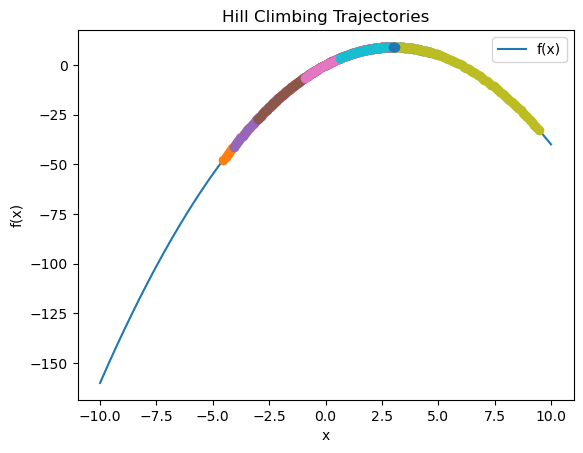

In [7]:
print(datetime.now())
print("F24-0688")

x_vals = np.linspace(-10,10,400)
y_vals = f(x_vals)

plt.plot(x_vals,y_vals,label="f(x)")

for path in paths:
    y_path = [f(x) for x in path]
    plt.plot(path,y_path,marker='o')

plt.xlabel("x")
plt.ylabel("f(x)")
plt.title("Hill Climbing Trajectories")
plt.legend()
plt.show()

Report:
The plot shows the trajectories of hill climbing from different starting
points. Since the function has a single global maximum at x = 3, most runs
eventually converge to that point. Random restart helps when functions
contain multiple local maxima. However, if the function already has a single
peak, restarting many times may be unnecessary and computationally wasteful.

# Question 11: Simulated Annealing for TSP


In [7]:
from datetime import datetime
import numpy as np
import random
import math
import matplotlib.pyplot as plt

## (a) State Representation and Neighbor Definition
- state is represented as a permutation of city indices
- neighbor is created by swapping two random cities in the route

In [9]:
print(datetime.now())
print("F24-0688")

cities = [(0,0),(1,5),(3,2),(6,4),(8,1),(7,7),(4,9),(2,7),(5,5),(9,3)]

def distance(a,b):
    return math.sqrt((a[0]-b[0])**2 + (a[1]-b[1])**2)

def total_distance(route):
    dist = 0
    for i in range(len(route)):
        city1 = cities[route[i]]
        city2 = cities[route[(i+1)%len(route)]]
        dist += distance(city1,city2)
    return dist

def random_neighbor(route):
    new_route = route.copy()
    i,j = random.sample(range(len(route)),2)
    new_route[i],new_route[j] = new_route[j],new_route[i]
    return new_route

2026-03-15 21:00:18.086999
F24-0688


Report:
Each solution is represented as an ordering of cities. A neighboring solution is generated by swapping two cities randomly in the route. This creates a slightly different tour that can be evaluated for improvement.

## (b) Simulated Annealing Algorithm
Initial Temperature = 1000  
Cooling Rate α = 0.995  
Iterations = 10,000  
Acceptance probability for worse solutions: P = e^(−ΔE / T)

In [11]:
print(datetime.now())
print("F24-0688")

def simulated_annealing():

    current = list(range(len(cities)))
    random.shuffle(current)

    best = current.copy()
    T = 1000
    alpha = 0.995

    costs = []

    for i in range(10000):

        neighbor = random_neighbor(current)

        curr_cost = total_distance(current)
        neigh_cost = total_distance(neighbor)

        delta = neigh_cost - curr_cost

        if delta < 0 or random.random() < math.exp(-delta/T):
            current = neighbor

        if total_distance(current) < total_distance(best):
            best = current.copy()

        costs.append(total_distance(current))

        T = T * alpha

    return best, costs

2026-03-15 21:02:46.010385
F24-0688


## (c) Run the Algorithm and Plot Cost vs Iteration

2026-03-15 21:16:40.922079
F24-0688
Best Route: [4, 9, 3, 8, 5, 6, 7, 1, 0, 2]
Total Distance: 32.11462300514698


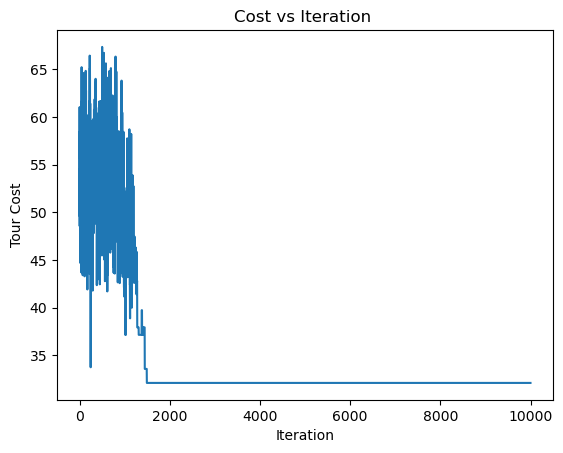

In [12]:
print(datetime.now())
print("F24-0688")

best_route, costs = simulated_annealing()

print("Best Route:", best_route)
print("Total Distance:", total_distance(best_route))

plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Tour Cost")
plt.title("Cost vs Iteration ")
plt.show()

Report:
The algorithm starts with a random tour and gradually improves it.
Sometimes worse solutions are accepted to escape local minima.
As temperature decreases, the algorithm becomes more selective
and eventually stabilizes near a good solution.

## (d) Cooling Schedule Experiment


2026-03-15 21:32:36.847126
F24-0688


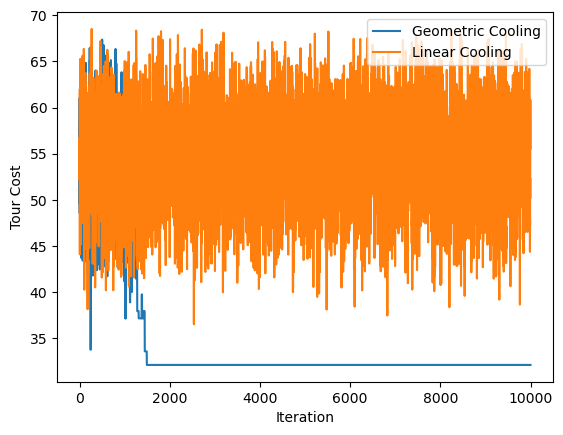

In [14]:
print(datetime.now())
print("F24-0688")

def simulated_annealing_linear():

    current = list(range(len(cities)))
    random.shuffle(current)

    T = 1000
    costs = []

    for i in range(10000):

        neighbor = random_neighbor(current)

        curr_cost = total_distance(current)
        neigh_cost = total_distance(neighbor)

        delta = neigh_cost - curr_cost

        if delta < 0 or random.random() < math.exp(-delta/T):
            current = neighbor

        costs.append(total_distance(current))

        T = T - 0.05
        if T <= 0:
            break

    return costs

linear_costs = simulated_annealing_linear()

plt.plot(costs,label="Geometric Cooling")
plt.plot(linear_costs,label="Linear Cooling")
plt.xlabel("Iteration")
plt.ylabel("Tour Cost")
plt.legend()
plt.show()

Report:
Geometric cooling reduces the temperature gradually using multiplication,
while linear cooling decreases temperature by subtraction.

Observation:
Geometric cooling typically converges more smoothly and maintains exploration
longer. Linear cooling reduces temperature faster, which may lead to quicker
convergence but increases the risk of getting stuck in local minima.

# Question 12: Local Beam Search for N-Queens (N = 8)

In [2]:
from datetime import datetime
import random
import numpy as np
from collections import Counter

## (a) State Representation and Heuristic

- State is represented as a list of length N where:
state[i] = row position of queen in column i

- Heuristic:
h(state) = number of non-attacking pairs of queens
Maximum possible value = N(N−1)/2.

In [3]:
print(datetime.now())
print("F24-0688")

N = 8

def heuristic(state):
    non_attacking = 0
    for i in range(N):
        for j in range(i+1, N):
            if state[i] != state[j] and abs(state[i]-state[j]) != abs(i-j):
                non_attacking += 1
    return non_attacking

2026-03-15 22:29:31.430324
F24-0688


## (b) Local Beam Search Implementation (k = 5)


In [4]:
print(datetime.now())
print("F24-0688")

def random_state():
    return [random.randint(0, N-1) for _ in range(N)]

def successors(state):
    succ = []
    for col in range(N):
        for row in range(N):
            if row != state[col]:
                new_state = state.copy()
                new_state[col] = row
                succ.append(new_state)
    return succ


def local_beam_search(k=5, max_iter=1000):

    states = [random_state() for _ in range(k)]
    goal = N*(N-1)//2

    for iteration in range(max_iter):

        scored = [(heuristic(s), s) for s in states]

        if any(score == goal for score,_ in scored):
            return True, iteration

        all_successors = []
        for s in states:
            for succ in successors(s):
                all_successors.append((heuristic(succ), succ))

        all_successors.sort(reverse=True, key=lambda x: x[0])
        new_states = [s for _,s in all_successors[:k]]

        if new_states == states:
            return False, iteration

        states = new_states

    return False, max_iter

2026-03-15 22:29:35.009839
F24-0688


## (c) Run 20 Trials
Measure:
1. Success Rate
2. Average iterations to success
3. Most common failure mode

In [5]:
print(datetime.now())
print("F24-0688")

runs = 20
success = 0
iterations = []
failures = []

for i in range(runs):

    result, it = local_beam_search()

    if result:
        success += 1
        iterations.append(it)
    else:
        failures.append("Local optimum")

success_rate = (success/runs)*100
avg_iter = sum(iterations)/len(iterations) if iterations else 0

print("Success Rate:", success_rate,"%")
print("Average Iterations:", avg_iter)
print("Failure Mode:", Counter(failures))

2026-03-15 22:29:37.863605
F24-0688
Success Rate: 70.0 %
Average Iterations: 4.142857142857143
Failure Mode: Counter({'Local optimum': 6})


Report:

Local Beam Search keeps k states simultaneously and explores successors of all
states. The algorithm selects the top k states with the highest heuristic value.

Observations:
- Success rate shows how often the algorithm finds a valid 8 queens solution.
- Failures occur when all beams converge to local optima with no improvement.

## (d) Stochastic Beam Search


In [6]:
print(datetime.now())
print("F24-0688")

def stochastic_beam_search(k=5, max_iter=1000):

    states = [random_state() for _ in range(k)]
    goal = N*(N-1)//2

    for iteration in range(max_iter):

        if any(heuristic(s) == goal for s in states):
            return True, iteration

        all_successors = []
        scores = []

        for s in states:
            for succ in successors(s):
                score = heuristic(succ)
                all_successors.append(succ)
                scores.append(score+1)

        probabilities = np.array(scores)/sum(scores)

        indices = np.random.choice(len(all_successors),k,p=probabilities)

        states = [all_successors[i] for i in indices]

    return False, max_iter

2026-03-15 22:50:54.719743
F24-0688


In [7]:
print(datetime.now())
print("F24-0688")

runs = 20
success = 0

for i in range(runs):

    result,_ = stochastic_beam_search()

    if result:
        success += 1

print("Stochastic Beam Success Rate:", (success/runs)*100,"%")

2026-03-15 22:51:19.530675
F24-0688
Stochastic Beam Success Rate: 5.0 %


Report:

Stochastic Beam Search introduces randomness when selecting successor states.
Instead of always choosing the best states, it samples states based on
their heuristic values.

Comparison:
- Deterministic Beam Search may converge faster but can get stuck in local optima.
- Stochastic Beam Search improves exploration and may increase success rate
in difficult search spaces like N-Queens.